# MWPM vs CM vs NCM (linear PPO) across code distances $d=3,5,7,9,11$

Compares three decoders on identical shots (mismatch = 1), as a function of surface-code distance:

- **MWPM** — plain minimum-weight matching (first pass).
- **CM** — native PyMatching correlated matching (`enable_correlations=True`).
- **NCM** — the linear PPO "Neural CM" agent. Its policy is **4 global coefficients**
  $(c_{\text{joint}},c_{\text{self}},c_{\text{nbr}},\text{bias})$, so it is **distance-independent**
  and applied *zero-shot* at every $d$ (trained at $d=5$). This notebook therefore also tests how
  well that learned damped policy **generalises across distances**.

For each $d$ we use $n_{\text{rounds}}=d$ (standard memory experiment) and sweep $p$, sizing each
point to a target #errors. Per distance we plot LER-vs-$p$; across distances we summarise the LER
reduction vs MWPM and the NCM/CM ratio.

> **Cost.** Large $d$ at low $p$ needs many shots and the NCM second pass is per-shot — defaults are
> a runnable preview (`MAX_SHOTS` cap). Raise `MAX_SHOTS`/`TARGET_ERR`, or drop cluster results into
> `PRECOMPUTED`, for publication-quality points. CM (native) and MWPM are batched and cheap; NCM is
> the bottleneck at large $d$.

In [ ]:
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pymatching
import torch

from NeuralCM.syndrome_data_generation import SyndromeDataGenerator
from NeuralCM.drifted_matching_env import DriftedMatchingEnv
from NeuralCM.linear_correlated_matching import LinearCorrelatedMatching

# ---- config ----
DISTANCES  = [3, 5, 7, 9]
P_SWEEP    = np.logspace(np.log10(1e-3), np.log10(8e-3), 5)
N_ROUNDS   = lambda d: d          # standard d-round memory experiment
BYPASS     = 2
HOPS       = 1
TARGET_ERR = 300                  # stop a (d,p) once every decoder hits this many errors
MAX_SHOTS  = 10000_000_000            # per (d,p) cap (raise for low p / large d)
CHUNK      = 100_000

def _find(rel):
    rel = Path(rel)
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / rel).exists():
            return str(base / rel)
    raise FileNotFoundError(f"could not locate {rel} from {Path.cwd()} upward")

MODEL_PATH = _find("models/linear/linear_model_ppo_0_best.pth")
ck = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)["actor"]
CJ, CS, CN, CB = (float(ck["coef_joint"]), float(ck["coef_self"]),
                  float(ck["coef_nbr"]),  float(ck["bias"]))
print(f"NCM (PPO) coefficients (applied at every d): "
      f"c_joint={CJ:.3f}  c_self={CS:.3f}  c_nbr={CN:.3f}  bias={CB:.3f}")

def ler_se(ler, n):
    return float(np.sqrt(ler * (1.0 - ler) / n)) if (n > 0 and 0 < ler < 1) else 0.0

In [ ]:
class DistProbe:
    """MWPM (first pass), CM (native enable_correlations) and NCM (linear PPO, 2-pass) on one (d, p).
    Build once per (d, p); call process(seed) per chunk (reset re-simulates fresh shots).

    NCM is the src decoder `LinearCorrelatedMatching` (the linear_cm agent's functional form),
    driven by the 4 coefficients loaded above -- no hand-rolled second pass here."""
    def __init__(self, p, distance, chunk=CHUNK, n_rounds=None, bypass=BYPASS, hops=HOPS):
        n_rounds = N_ROUNDS(distance) if n_rounds is None else n_rounds
        gen = SyndromeDataGenerator(
            distance=distance, n_rounds=n_rounds, mismatch=1.0,
            noise_model={'version': 'built-in',
                         'after_clifford_depolarization': p,
                         'before_measure_flip_probability': p,
                         'after_reset_flip_probability': p,
                         'before_round_data_depolarization': p,
                         'p_gate_zz': 0.0},
            memory_type='z', n_shots=chunk, qec_code='surface_code')
        self.env = DriftedMatchingEnv(
            syndrome_data_generator=gen, local_action_only=True, local_action_hops=hops,
            action_scale=1.0, update_period=chunk + 1, n_test_shots=0,
            use_pearson_correlation=False, use_log_joint_prob=True,
            start_from_oracle=True, train_mode=True)
        self.env.reset(seed=0)
        env = self.env
        self.fault = env.fault_array
        self.matching = pymatching.Matching.from_check_matrix(env.H, weights=env.current_weights)
        self._m_corr  = pymatching.Matching.from_detector_error_model(env.base_dem, enable_correlations=True)
        # NCM = linear-coefficient correlated matching (src decoder), same coeffs / bypass / hops.
        self.ncm = LinearCorrelatedMatching(
            env.base_dem, coef_joint=CJ, coef_self=CS, coef_nbr=CN, bias=CB,
            action_scale=1.0, bypass_threshold=bypass, local_action_hops=hops, chunk_size=chunk)

    def process(self, seed):
        env = self.env
        env.reset(seed=seed)
        shots = env.syndrome_batch; true = env.true_obs_batch; n = len(shots)
        ef = np.asarray(self.matching.decode_batch(shots, enable_correlations=False), dtype=bool)
        first_obs = (ef.astype(np.int64) @ self.fault) % 2
        mwpm_err = int(np.sum(first_obs != true))
        nat = np.asarray(self._m_corr.decode_batch(shots, enable_correlations=True)).reshape(n, -1)
        nat = (nat.sum(1) % 2) if nat.shape[1] > 1 else nat[:, 0]
        cm_err = int(np.sum(nat.astype(true.dtype) != true))
        ncm_pred = self.ncm.decode_batch(shots)[:, 0]
        ncm_err = int(np.sum(ncm_pred.astype(true.dtype) != true))
        return mwpm_err, cm_err, ncm_err, n

print("DistProbe defined.")

## Run the (distance x p) sweep

In [ ]:
# Optional: paste cluster results to skip the measurement.
# Format: PRECOMPUTED[d][decoder] = {'p':[...], 'errors':[...], 'shots':[...]}  (decoders: MWPM/CM/NCM)
PRECOMPUTED = {}

DECODERS = ['MWPM', 'CM', 'NCM']

def measure():
    results = {d: {m: {'p': [], 'ler': [], 'se': [], 'errors': [], 'shots': []} for m in DECODERS}
               for d in DISTANCES}
    for d in DISTANCES:
        for pv in P_SWEEP:
            probe = DistProbe(pv, d)
            tot = {m: 0 for m in DECODERS}; shots = 0; ci = 0; t0 = time.time()
            while shots < MAX_SHOTS:
                mwpm_e, cm_e, ncm_e, n = probe.process(seed=3000 + ci)
                tot['MWPM'] += mwpm_e; tot['CM'] += cm_e; tot['NCM'] += ncm_e
                shots += n; ci += 1
                if min(tot.values()) >= TARGET_ERR:
                    break
            for m in DECODERS:
                ler = tot[m] / shots
                results[d][m]['p'].append(pv); results[d][m]['ler'].append(ler)
                results[d][m]['se'].append(ler_se(ler, shots))
                results[d][m]['errors'].append(tot[m]); results[d][m]['shots'].append(shots)
            print(f"d={d:2d} p={pv:.2e} shots={shots:>9,} ({time.time()-t0:4.0f}s) | "
                  + ' | '.join(f"{m}:{tot[m]:>4d}({tot[m]/shots:.2e})" for m in DECODERS))
    return results

def from_precomputed(pre):
    results = {}
    for d, dec in pre.items():
        results[d] = {}
        for m, dd in dec.items():
            p = np.asarray(dd['p'], float); err = np.asarray(dd['errors'], float)
            sh = np.asarray(dd['shots'], float) * np.ones_like(p); ler = err / sh
            results[d][m] = {'p': list(p), 'ler': list(ler),
                             'se': [ler_se(l, n) for l, n in zip(ler, sh)],
                             'errors': list(err), 'shots': list(sh)}
    return results

results = from_precomputed(PRECOMPUTED) if PRECOMPUTED else measure()
print("\ndistances:", list(results))

d= 3 p=1.00e-03 shots=  500,000 (   1s) | MWPM: 364(7.28e-04) | CM: 322(6.44e-04) | NCM: 328(6.56e-04)
d= 3 p=1.68e-03 shots=  200,000 (   1s) | MWPM: 405(2.02e-03) | CM: 375(1.87e-03) | NCM: 381(1.91e-03)
d= 3 p=2.83e-03 shots=  100,000 (   1s) | MWPM: 529(5.29e-03) | CM: 476(4.76e-03) | NCM: 499(4.99e-03)
d= 3 p=4.76e-03 shots=  100,000 (   1s) | MWPM:1563(1.56e-02) | CM:1405(1.40e-02) | NCM:1473(1.47e-02)
d= 3 p=8.00e-03 shots=  100,000 (   2s) | MWPM:3891(3.89e-02) | CM:3642(3.64e-02) | NCM:3728(3.73e-02)
d= 5 p=1.00e-03 shots=3,800,000 (  76s) | MWPM: 516(1.36e-04) | CM: 308(8.11e-05) | NCM: 326(8.58e-05)
d= 5 p=1.68e-03 shots=  800,000 (  26s) | MWPM: 496(6.20e-04) | CM: 314(3.92e-04) | NCM: 330(4.12e-04)
d= 5 p=2.83e-03 shots=  200,000 (   9s) | MWPM: 538(2.69e-03) | CM: 365(1.83e-03) | NCM: 385(1.93e-03)
d= 5 p=4.76e-03 shots=  100,000 (   6s) | MWPM:1235(1.23e-02) | CM: 855(8.55e-03) | NCM: 893(8.93e-03)
d= 5 p=8.00e-03 shots=  100,000 (   8s) | MWPM:4751(4.75e-02) | CM:3829(3

## LER vs p, one panel per distance

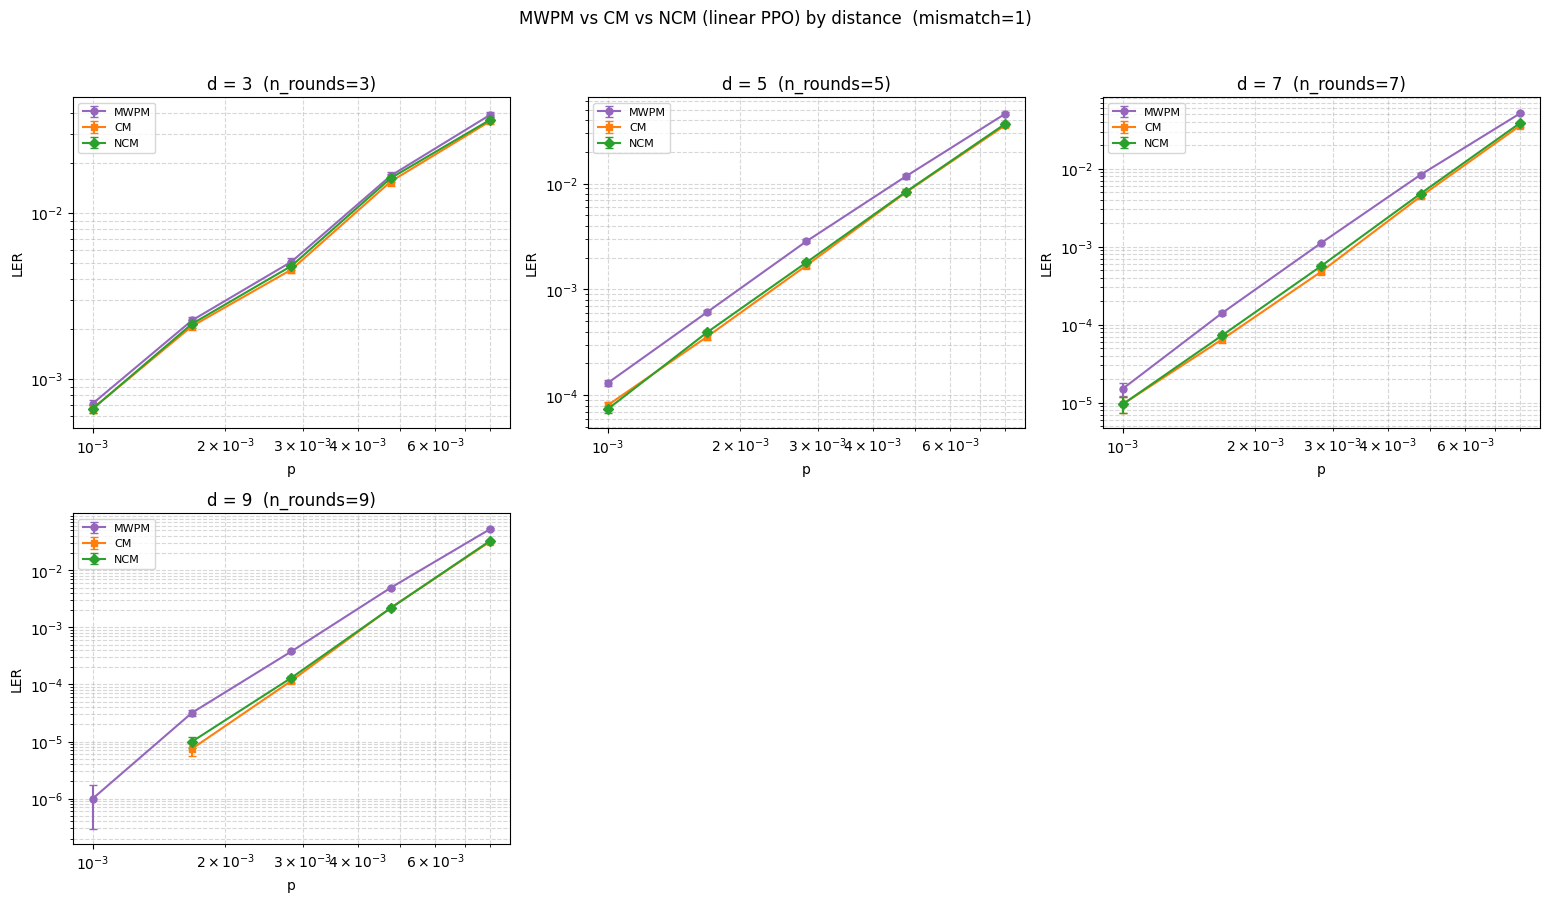

In [ ]:
sty = {'MWPM': ('#9467bd', 'o'), 'CM': ('#ff7f0e', 's'), 'NCM': ('#2ca02c', 'D')}
ds = list(results)
ncol = min(3, len(ds)); nrow = int(np.ceil(len(ds) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.2*ncol, 4.4*nrow), squeeze=False)
for ax in axes.flat[len(ds):]:
    ax.axis('off')
for ax, d in zip(axes.flat, ds):
    for m in DECODERS:
        r = results[d][m]; p = np.array(r['p']); ler = np.array(r['ler'], float); se = np.array(r['se'])
        c, mk = sty[m]
        ax.errorbar(p, np.where(ler > 0, ler, np.nan), yerr=se, marker=mk, color=c,
                    capsize=3, lw=1.5, ms=5, label=m)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'd = {d}  (n_rounds={d})'); ax.set_xlabel('p'); ax.set_ylabel('LER')
    ax.grid(True, which='both', ls='--', alpha=0.5); ax.legend(fontsize=8)
fig.suptitle('MWPM vs CM vs NCM (linear PPO) by distance  (mismatch=1)', y=1.02)
fig.tight_layout(); plt.show()

## Summary across distances

Left: LER reduction vs MWPM (%) at the **lowest measured p**, per distance — does NCM keep its edge
(and does CM's collapse) as $d$ grows? Right: **NCM/CM ratio** vs $p$, one line per distance
(<1 means NCM beats CM).

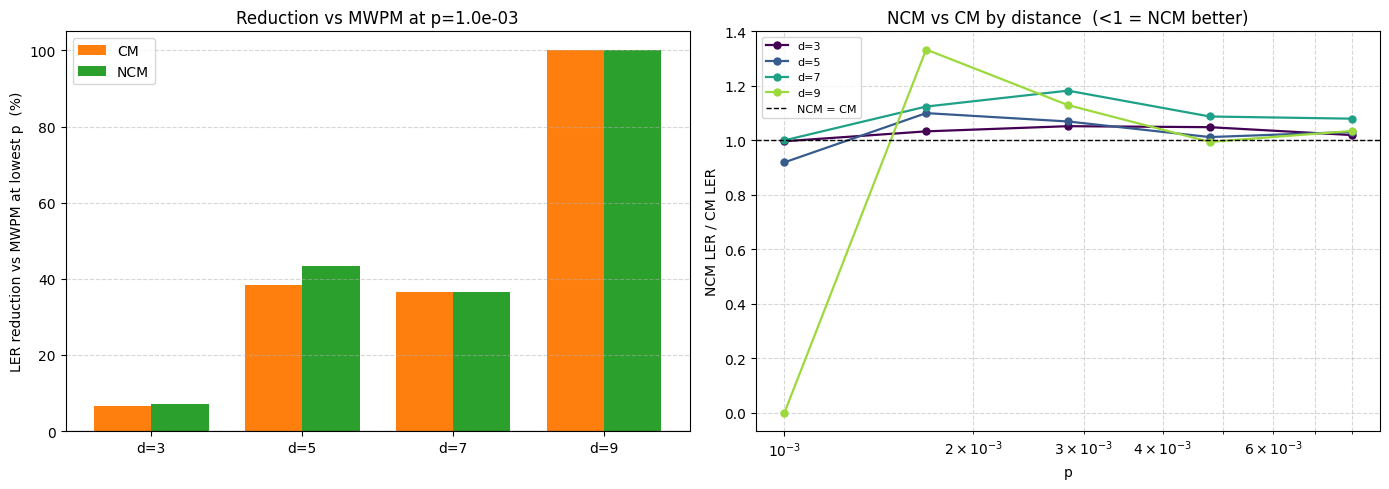

  d          p       MWPM         CM        NCM  CM red%  NCM red%
  3   1.00e-03   7.11e-04   6.63e-04   6.61e-04      6.7       7.0
  3   1.68e-03   2.26e-03   2.08e-03   2.15e-03      7.8       4.7
  3   2.83e-03   5.09e-03   4.56e-03   4.80e-03     10.3       5.7
  3   4.76e-03   1.68e-02   1.55e-02   1.63e-02      7.7       3.3
  3   8.00e-03   3.91e-02   3.58e-02   3.65e-02      8.4       6.6
  5   1.00e-03   1.31e-04   8.05e-05   7.40e-05     38.3      43.3
  5   1.68e-03   6.10e-04   3.57e-04   3.93e-04     41.4      35.5
  5   2.83e-03   2.85e-03   1.68e-03   1.80e-03     40.9      36.8
  5   4.76e-03   1.17e-02   8.25e-03   8.35e-03     29.5      28.6
  5   8.00e-03   4.57e-02   3.55e-02   3.67e-02     22.1      19.7
  7   1.00e-03   1.50e-05   9.50e-06   9.50e-06     36.7      36.7
  7   1.68e-03   1.40e-04   6.45e-05   7.25e-05     54.1      48.4
  7   2.83e-03   1.12e-03   4.80e-04   5.67e-04     57.2      49.4
  7   4.76e-03   8.40e-03   4.43e-03   4.81e-03     47.3      

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- (left) % reduction vs MWPM at the lowest p, grouped by distance ---
x = np.arange(len(ds)); width = 0.38
def red_at_lowp(m):
    out = []
    for d in ds:
        i = int(np.argmin(results[d]['MWPM']['p']))   # lowest-p index
        mw = results[d]['MWPM']['ler'][i]; v = results[d][m]['ler'][i]
        out.append(100*(1 - v/mw) if mw > 0 else np.nan)
    return np.array(out)
cm_red, ncm_red = red_at_lowp('CM'), red_at_lowp('NCM')
ax1.bar(x - width/2, cm_red, width, color='#ff7f0e', label='CM')
ax1.bar(x + width/2, ncm_red, width, color='#2ca02c', label='NCM')
ax1.set_xticks(x); ax1.set_xticklabels([f'd={d}' for d in ds])
ax1.set_ylabel('LER reduction vs MWPM at lowest p  (%)')
lowp = results[ds[0]]['MWPM']['p'][int(np.argmin(results[ds[0]]['MWPM']['p']))]
ax1.set_title(f'Reduction vs MWPM at p={lowp:.1e}')
ax1.axhline(0, color='k', lw=0.8); ax1.legend(); ax1.grid(axis='y', ls='--', alpha=0.5)

# --- (right) NCM/CM ratio vs p per distance ---
cmap = plt.cm.viridis(np.linspace(0, 0.85, len(ds)))
for d, col in zip(ds, cmap):
    p = np.array(results[d]['CM']['p'])
    ratio = np.array(results[d]['NCM']['ler']) / np.maximum(np.array(results[d]['CM']['ler']), 1e-300)
    ax2.plot(p, ratio, marker='o', color=col, lw=1.6, ms=5, label=f'd={d}')
ax2.axhline(1.0, color='k', ls='--', lw=1, label='NCM = CM')
ax2.set_xscale('log'); ax2.set_xlabel('p'); ax2.set_ylabel('NCM LER / CM LER')
ax2.set_title('NCM vs CM by distance  (<1 = NCM better)')
ax2.grid(True, which='both', ls='--', alpha=0.5); ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

# table
print(f"{'d':>3} {'p':>10} {'MWPM':>10} {'CM':>10} {'NCM':>10} {'CM red%':>8} {'NCM red%':>9}")
for d in ds:
    for i in range(len(results[d]['MWPM']['p'])):
        p = results[d]['MWPM']['p'][i]
        mw = results[d]['MWPM']['ler'][i]; cm = results[d]['CM']['ler'][i]; nc = results[d]['NCM']['ler'][i]
        print(f"{d:>3} {p:>10.2e} {mw:>10.2e} {cm:>10.2e} {nc:>10.2e} "
              f"{100*(1-cm/mw) if mw>0 else 0:>8.1f} {100*(1-nc/mw) if mw>0 else 0:>9.1f}")

## Takeaways

- **Per-distance panels** show whether the MWPM < CM < NCM ordering (and CM's low-p degradation)
  holds as $d$ grows, and whether the NCM advantage survives — a key generalisation test, since the
  **same 4 coefficients** (trained at $d=5$) are applied at every $d$.
- **Reduction-vs-distance (left)**: if NCM's bar stays high while CM's shrinks as $d$ grows, the
  damped policy generalises and the free-edge over-correction hurts CM more at larger $d$ (longer
  shortcuts available).
- **NCM/CM ratio (right)**: lines below 1 at low $p$, trending toward 1 at higher $p$ (the crossover)
  for each distance; watch whether the crossover $p$ shifts with $d$.

**Caveats.** Low-$p$ / large-$d$ points are shot-limited at the default `MAX_SHOTS` (sparse, noisy);
scale up or paste cluster data. `n_rounds=d` by default — change `N_ROUNDS` to hold rounds fixed if
you want to isolate the spatial distance. NCM uses the $d=5$-trained coefficients unchanged, so any
degradation at extreme $d$ is a *generalisation* effect, not a per-$d$ refit.